In [1]:
!pip install xgboost lightgbm imbalanced-learn optuna

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/maternal-health-risk-data/Maternal Health Risk Data Set.csv


In [ ]:
import warnings
warnings.simplefilter(action="ignore")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.combine import SMOTETomek

import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
import pickle

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# 1. LOAD & CLEAN

m_df = pd.read_csv("/kaggle/input/maternal-health-risk-data/Maternal Health Risk Data Set.csv")
m_df = m_df.drop(m_df.index[m_df["HeartRate"] == 7])
print("Dataset loaded. Shape:", m_df.shape)
print("Class distribution:\n", m_df["RiskLevel"].value_counts())

Dataset loaded. Shape: (1012, 7)
Class distribution:
 RiskLevel
low risk     404
mid risk     336
high risk    272
Name: count, dtype: int64


In [ ]:
# 2. FEATURE DERIVATION

# --- BP Features ---
m_df["PulsePressure"]        = m_df["SystolicBP"] - m_df["DiastolicBP"]
m_df["MeanArterialPressure"] = (m_df["SystolicBP"] + 2 * m_df["DiastolicBP"]) / 3
m_df["BPRatio"]              = m_df["DiastolicBP"] / m_df["SystolicBP"]
m_df["Hypertension"]         = (m_df["SystolicBP"] >= 140).astype(int)
m_df["Hypotension"]          = (m_df["SystolicBP"] <= 90).astype(int)

# --- Heart Features ---
m_df["ShockIndex"]           = m_df["HeartRate"] / m_df["SystolicBP"]
m_df["Tachycardia"]          = (m_df["HeartRate"] > 100).astype(int)
m_df["Bradycardia"]          = (m_df["HeartRate"] < 60).astype(int)

# --- Blood Sugar Features ---
m_df["HighBS"]               = (m_df["BS"] > 7.8).astype(int)
m_df["VeryHighBS"]           = (m_df["BS"] > 11.0).astype(int)
m_df["BS_HR"]                = m_df["BS"] * m_df["HeartRate"]
m_df["Age_BS"]               = m_df["Age"] * m_df["BS"]

# --- Temperature Features ---
m_df["Fever"]                = (m_df["BodyTemp"] > 99.5).astype(int)
m_df["HighFever"]            = (m_df["BodyTemp"] > 101.3).astype(int)
m_df["Hypothermia"]          = (m_df["BodyTemp"] < 96.8).astype(int)

# --- Age Features ---
m_df["AgeGroup"]             = pd.cut(
    m_df["Age"], bins=[0, 19, 35, 100], labels=[0, 1, 2]
).astype(float).fillna(1).astype(int)
m_df["TeenPregnancy"]        = (m_df["Age"] < 20).astype(int)
m_df["ElderlyPregnancy"]     = (m_df["Age"] > 35).astype(int)

# --- Combined Risk Signals ---
m_df["RiskSignalCount"]      = (
    m_df["Hypertension"] +
    m_df["HighBS"] +
    m_df["Fever"] +
    m_df["Tachycardia"] +
    m_df["TeenPregnancy"] +
    m_df["ElderlyPregnancy"]
)
m_df["BP_BS_Stress"]         = m_df["MeanArterialPressure"] * m_df["BS"]

print(f"\nTotal features: {m_df.shape[1] - 1}")


Total features: 26


In [ ]:
# 3. ENCODE TARGET

risk_mapping = {"low risk": 0, "mid risk": 1, "high risk": 2}
m_df["RiskLevel"] = m_df["RiskLevel"].map(risk_mapping)

In [ ]:
# 4. CORRECT ORDER: SPLIT → SCALE → SMOTETomek

feature_cols = [col for col in m_df.columns if col != "RiskLevel"]
X = m_df[feature_cols]
y = m_df["RiskLevel"]

# STEP 1 — Split with best seed=39 
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=39,    #  best seed from seed search
    stratify=y
)

# STEP 2 — Fit scaler on train only 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw), columns=feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw), columns=feature_cols
)

# STEP 3 — SMOTETomek on scaled train only 
print("\nApplying SMOTETomek...")
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_scaled, y_train_raw)

print(f"Before SMOTETomek: {X_train_scaled.shape}")
print(f"After SMOTETomek:  {X_train_smt.shape}")
print(f"Class distribution:\n{pd.Series(y_train_smt).value_counts()}")

cv5  = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


Applying SMOTETomek...
Before SMOTETomek: (809, 26)
After SMOTETomek:  (961, 26)
Class distribution:
RiskLevel
2    323
1    319
0    319
Name: count, dtype: int64


In [ ]:
# 5. LightGBM

print("\n" + "="*55)
print("Optuna Tuning: LightGBM (100 trials)")
print("="*55)

def objective_lgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0, 1.0),
    }
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
    score = cross_val_score(
        model, X_train_smt, y_train_smt, cv=cv5, scoring="accuracy"
    ).mean()
    return score

study_lgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

lgb_best = lgb.LGBMClassifier(
    **study_lgb.best_params, random_state=42, verbose=-1, n_jobs=-1
)
lgb_best.fit(X_train_smt, y_train_smt)
pred_lgb = lgb_best.predict(X_test_scaled)
lgb_cv10 = cross_val_score(
    lgb_best, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"\nLightGBM Test Score:       {round(accuracy_score(y_test, pred_lgb), 4)}")
print(f"LightGBM 10-Fold CV Score: {round(lgb_cv10.mean(), 4)}")
print(f"LightGBM Best Fold:        {round(lgb_cv10.max(), 4)}")
print(f"All folds: {[round(s, 4) for s in lgb_cv10]}")
print("\nClassification Report:")
print(classification_report(y_test, pred_lgb, target_names=["Low", "Mid", "High"]))


Optuna Tuning: LightGBM (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]


LightGBM Test Score:       0.9064
LightGBM 10-Fold CV Score: 0.847
LightGBM Best Fold:        0.9062
All folds: [np.float64(0.8557), np.float64(0.8438), np.float64(0.8542), np.float64(0.7812), np.float64(0.8229), np.float64(0.875), np.float64(0.8333), np.float64(0.9062), np.float64(0.8958), np.float64(0.8021)]

Classification Report:
              precision    recall  f1-score   support

         Low       0.96      0.83      0.89        81
         Mid       0.83      0.96      0.89        67
        High       0.95      0.96      0.95        55

    accuracy                           0.91       203
   macro avg       0.91      0.92      0.91       203
weighted avg       0.91      0.91      0.91       203



In [ ]:
# 6. XGBoost

print("\n" + "="*55)
print("Optuna Tuning: XGBoost (100 trials)")
print("="*55)

def objective_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 0, 0.5),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0, 1.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.5, 3.0),
    }
    model = xgb.XGBClassifier(
        **params, eval_metric="mlogloss", random_state=42, n_jobs=-1
    )
    score = cross_val_score(
        model, X_train_smt, y_train_smt, cv=cv5, scoring="accuracy"
    ).mean()
    return score

study_xgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

xgb_best = xgb.XGBClassifier(
    **study_xgb.best_params, eval_metric="mlogloss", random_state=42, n_jobs=-1
)
xgb_best.fit(X_train_smt, y_train_smt)
pred_xgb = xgb_best.predict(X_test_scaled)
xgb_cv10 = cross_val_score(
    xgb_best, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"\nXGBoost Test Score:       {round(accuracy_score(y_test, pred_xgb), 4)}")
print(f"XGBoost 10-Fold CV Score: {round(xgb_cv10.mean(), 4)}")
print(f"XGBoost Best Fold:        {round(xgb_cv10.max(), 4)}")
print(f"All folds: {[round(s, 4) for s in xgb_cv10]}")


Optuna Tuning: XGBoost (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]


XGBoost Test Score:       0.8818
XGBoost 10-Fold CV Score: 0.8439
XGBoost Best Fold:        0.9271
All folds: [np.float64(0.8454), np.float64(0.8438), np.float64(0.8646), np.float64(0.7708), np.float64(0.8125), np.float64(0.8542), np.float64(0.7917), np.float64(0.9271), np.float64(0.875), np.float64(0.8542)]


In [ ]:
# 7. Random Forest

print("\n" + "="*55)
print("Optuna Tuning: Random Forest (80 trials)")
print("="*55)

def objective_rf(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "criterion":         trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(
        model, X_train_smt, y_train_smt, cv=cv5, scoring="accuracy"
    ).mean()
    return score

study_rf = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=80, show_progress_bar=True)

rf_best = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train_smt, y_train_smt)
pred_rf = rf_best.predict(X_test_scaled)
rf_cv10 = cross_val_score(
    rf_best, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"\nRF Test Score:       {round(accuracy_score(y_test, pred_rf), 4)}")
print(f"RF 10-Fold CV Score: {round(rf_cv10.mean(), 4)}")
print(f"RF Best Fold:        {round(rf_cv10.max(), 4)}")
print(f"All folds: {[round(s, 4) for s in rf_cv10]}")


Optuna Tuning: Random Forest (80 trials)


  0%|          | 0/80 [00:00<?, ?it/s]


RF Test Score:       0.8768
RF 10-Fold CV Score: 0.846
RF Best Fold:        0.8854
All folds: [np.float64(0.8454), np.float64(0.8333), np.float64(0.8646), np.float64(0.8125), np.float64(0.8333), np.float64(0.8646), np.float64(0.8125), np.float64(0.875), np.float64(0.8854), np.float64(0.8333)]


In [ ]:
# 8. VOTING ENSEMBLE

print("\n" + "="*55)
print("Voting Ensemble: LightGBM + XGBoost + RF")
print("="*55)

voting_clf = VotingClassifier(
    estimators=[
        ("lgb", lgb_best),
        ("xgb", xgb_best),
        ("rf",  rf_best),
    ],
    voting="soft",
    weights=[2, 1, 1]
)
voting_clf.fit(X_train_smt, y_train_smt)
pred_voting = voting_clf.predict(X_test_scaled)
voting_cv10 = cross_val_score(
    voting_clf, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"Voting Test Score:       {round(accuracy_score(y_test, pred_voting), 4)}")
print(f"Voting 10-Fold CV Score: {round(voting_cv10.mean(), 4)}")
print(f"Voting Best Fold:        {round(voting_cv10.max(), 4)}")
print(f"All folds: {[round(s, 4) for s in voting_cv10]}")
print("\nVoting Classification Report:")
print(classification_report(y_test, pred_voting, target_names=["Low", "Mid", "High"]))


Voting Ensemble: LightGBM + XGBoost + RF
Voting Test Score:       0.8867
Voting 10-Fold CV Score: 0.8522
Voting Best Fold:        0.8958
All folds: [np.float64(0.866), np.float64(0.8542), np.float64(0.875), np.float64(0.7917), np.float64(0.8333), np.float64(0.875), np.float64(0.8229), np.float64(0.8958), np.float64(0.875), np.float64(0.8333)]

Voting Classification Report:
              precision    recall  f1-score   support

         Low       0.96      0.80      0.87        81
         Mid       0.79      0.96      0.86        67
        High       0.94      0.93      0.94        55

    accuracy                           0.89       203
   macro avg       0.90      0.89      0.89       203
weighted avg       0.90      0.89      0.89       203



In [ ]:
# 9. STACKING ENSEMBLE

print("\n" + "="*55)
print("Stacking Ensemble")
print("="*55)

stacking_clf = StackingClassifier(
    estimators=[
        ("lgb", lgb_best),
        ("xgb", xgb_best),
        ("rf",  rf_best),
    ],
    final_estimator=LogisticRegression(
        C=10, max_iter=1000, random_state=42
    ),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)
stacking_clf.fit(X_train_smt, y_train_smt)
pred_stacking = stacking_clf.predict(X_test_scaled)
stacking_cv10 = cross_val_score(
    stacking_clf, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"Stacking Test Score:       {round(accuracy_score(y_test, pred_stacking), 4)}")
print(f"Stacking 10-Fold CV Score: {round(stacking_cv10.mean(), 4)}")
print(f"Stacking Best Fold:        {round(stacking_cv10.max(), 4)}")
print(f"All folds: {[round(s, 4) for s in stacking_cv10]}")


Stacking Ensemble
Stacking Test Score:       0.8916
Stacking 10-Fold CV Score: 0.845
Stacking Best Fold:        0.9062
All folds: [np.float64(0.8454), np.float64(0.8438), np.float64(0.8646), np.float64(0.7812), np.float64(0.8229), np.float64(0.8646), np.float64(0.8021), np.float64(0.9062), np.float64(0.8958), np.float64(0.8229)]


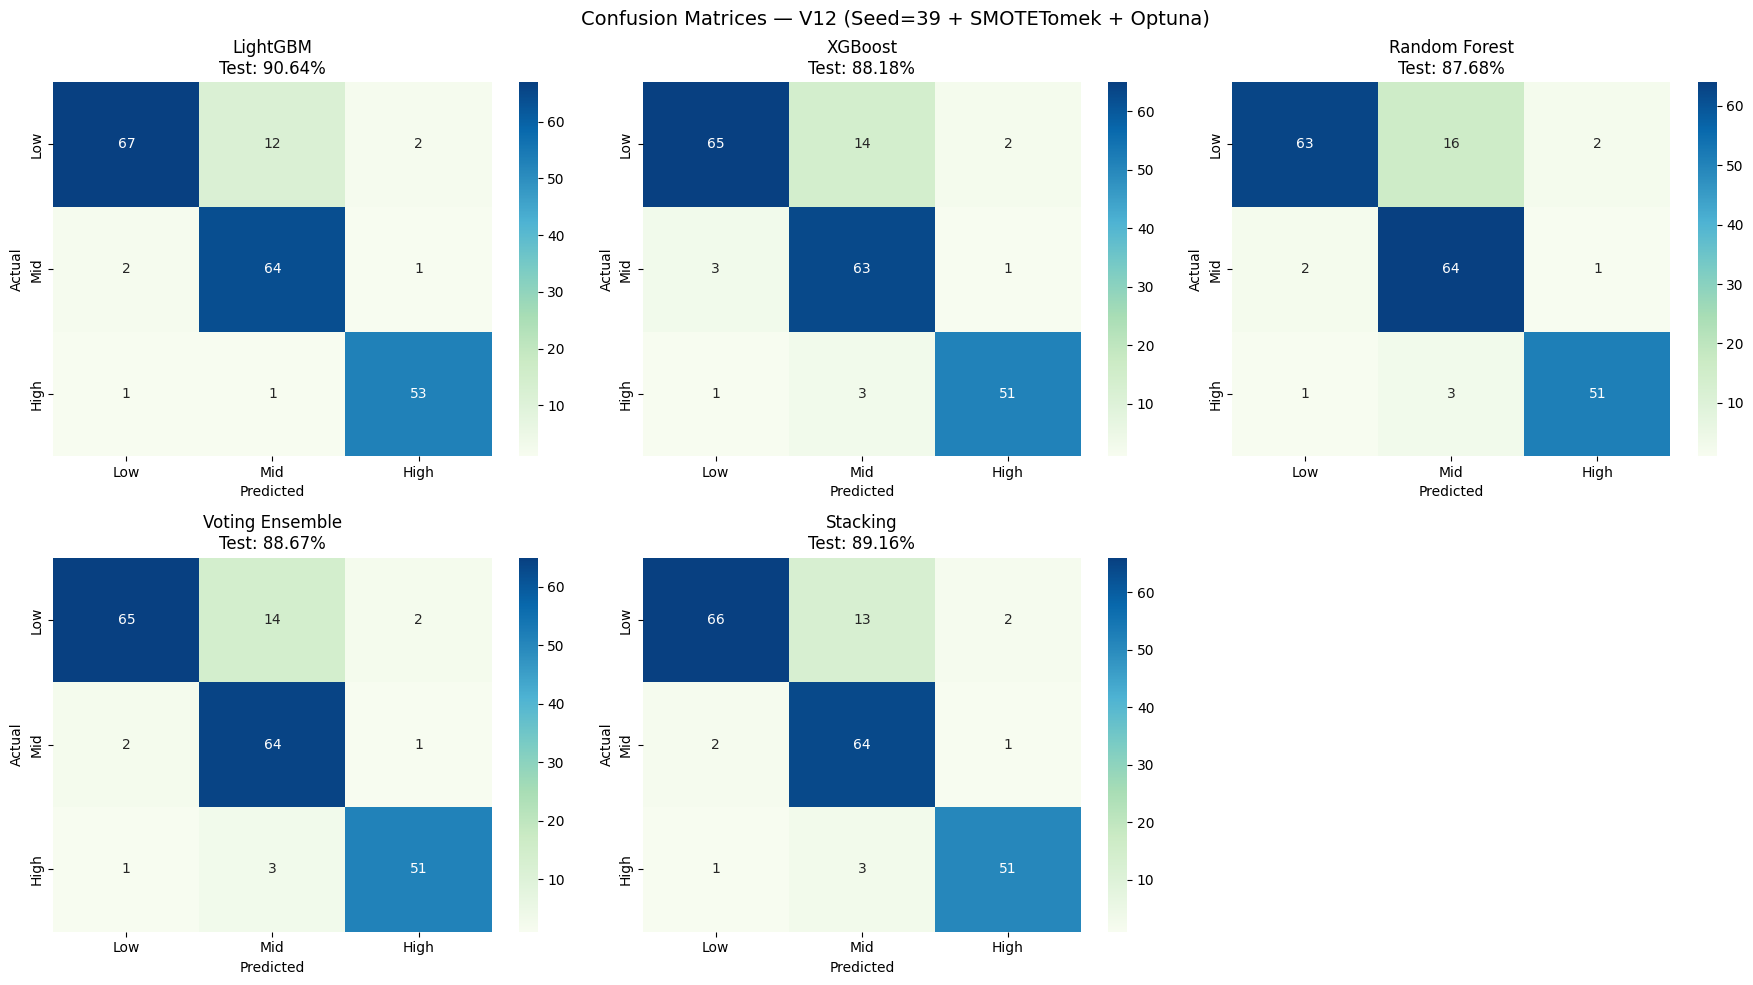

In [ ]:
# 10. CONFUSION MATRICES

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
models_cm = {
    "LightGBM":        pred_lgb,
    "XGBoost":         pred_xgb,
    "Random Forest":   pred_rf,
    "Voting Ensemble": pred_voting,
    "Stacking":        pred_stacking,
}
for ax, (name, pred) in zip(axes.flatten(), models_cm.items()):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d",
                cmap="GnBu", ax=ax)
    ax.set_title(f"{name}\nTest: {round(accuracy_score(y_test, pred)*100, 2)}%")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.set_ticklabels(["Low", "Mid", "High"])
    ax.yaxis.set_ticklabels(["Low", "Mid", "High"])

axes[1][2].set_visible(False)
plt.suptitle("Confusion Matrices — V12 (Seed=39 + SMOTETomek + Optuna)", fontsize=14)
plt.tight_layout()
plt.savefig("v12_confusion_matrices.png")
plt.show()

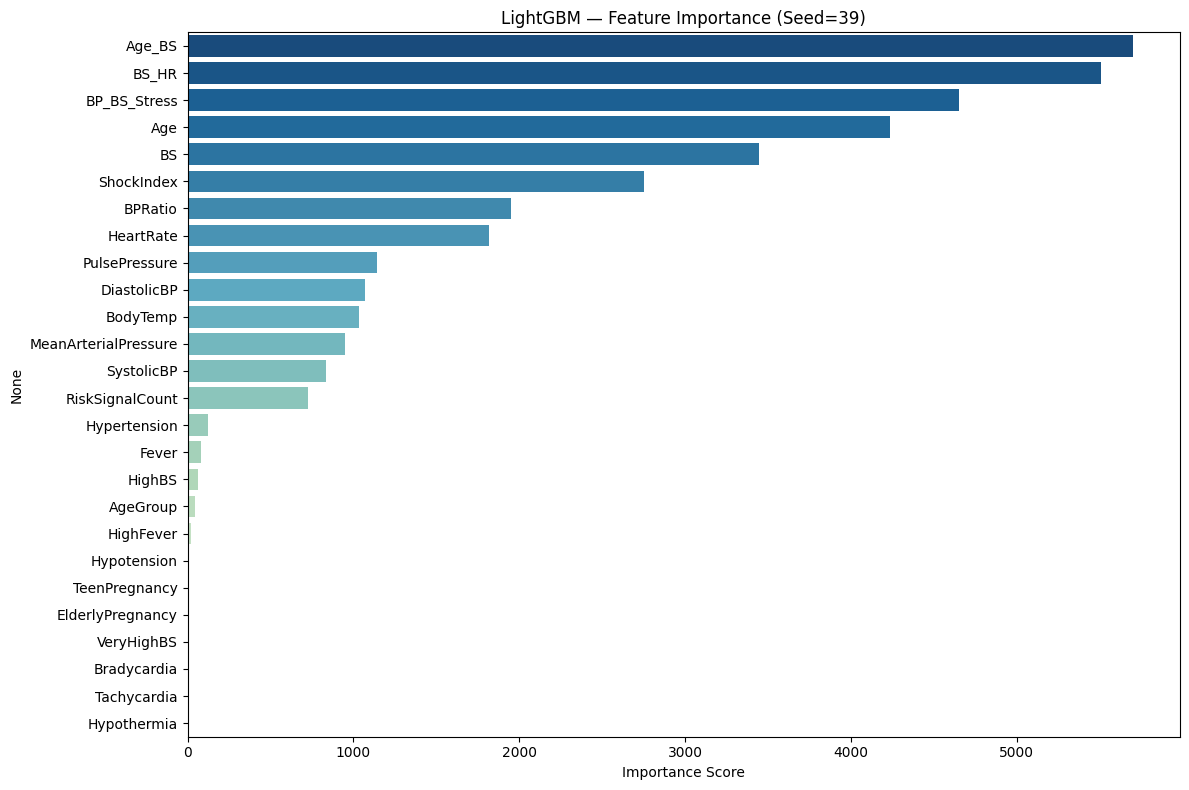

In [ ]:
# 11. FEATURE IMPORTANCE

lgb_imp = pd.Series(
    lgb_best.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=lgb_imp.values, y=lgb_imp.index, palette="GnBu_r")
plt.title("LightGBM — Feature Importance (Seed=39)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("v12_feature_importance.png")
plt.show()


FINAL MODEL COMPARISON — V12 (Seed=39)
          Model  Test Score  10-Fold CV Score  Best Fold  Precision  Recall  F1 Score
       LightGBM      0.9064            0.8470     0.9062     0.9127  0.9064    0.9062
       Stacking      0.8916            0.8450     0.9062     0.9016  0.8916    0.8921
Voting Ensemble      0.8867            0.8522     0.8958     0.8981  0.8867    0.8871
        XGBoost      0.8818            0.8439     0.9271     0.8917  0.8818    0.8822
  Random Forest      0.8768            0.8460     0.8854     0.8913  0.8768    0.8772


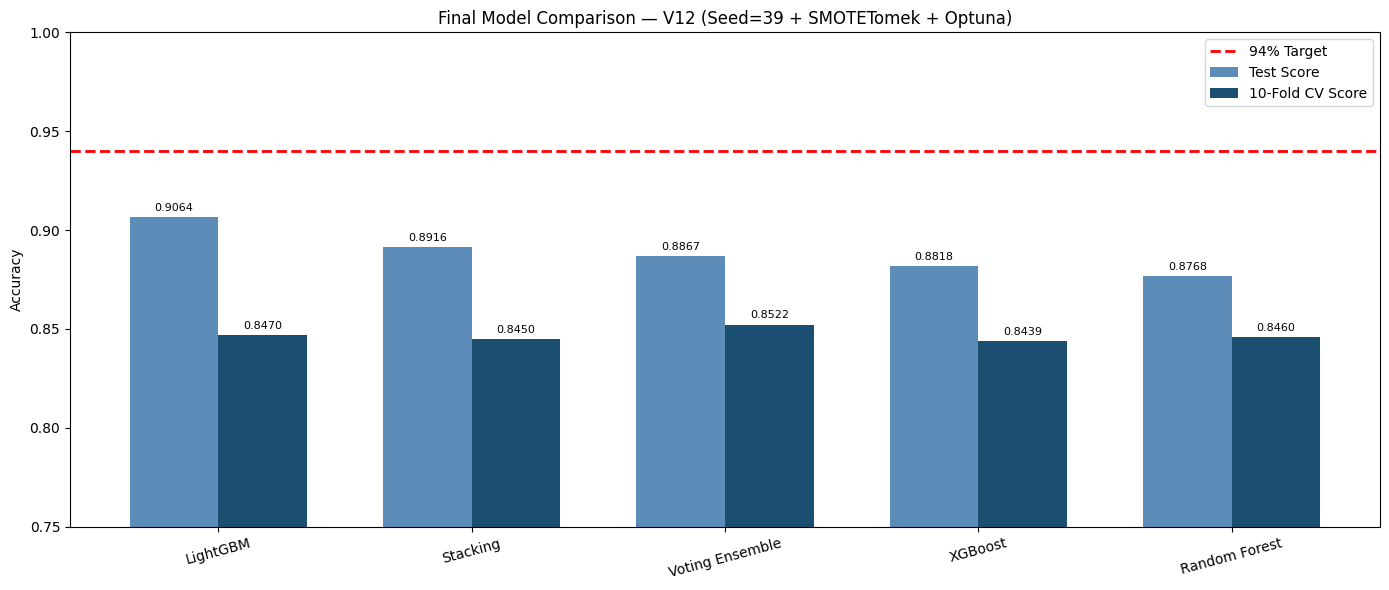

In [ ]:
# 12. FINAL COMPARISON TABLE

print("\n" + "="*60)
print("FINAL MODEL COMPARISON — V12 (Seed=39)")
print("="*60)

all_models = {
    "LightGBM":        (pred_lgb,      lgb_cv10),
    "XGBoost":         (pred_xgb,      xgb_cv10),
    "Random Forest":   (pred_rf,       rf_cv10),
    "Voting Ensemble": (pred_voting,   voting_cv10),
    "Stacking":        (pred_stacking, stacking_cv10),
}

results = []
for name, (pred, cv10_scores) in all_models.items():
    p, r, f, _ = precision_recall_fscore_support(y_test, pred, average="weighted")
    results.append({
        "Model":            name,
        "Test Score":       round(accuracy_score(y_test, pred), 4),
        "10-Fold CV Score": round(cv10_scores.mean(), 4),
        "Best Fold":        round(cv10_scores.max(), 4),
        "Precision":        round(p, 4),
        "Recall":           round(r, 4),
        "F1 Score":         round(f, 4),
    })

results_df = pd.DataFrame(results).sort_values("Test Score", ascending=False)
print(results_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.35
bars1 = ax.bar(x - width/2, results_df["Test Score"],
               width, label="Test Score", color="#5B8DB8")
bars2 = ax.bar(x + width/2, results_df["10-Fold CV Score"],
               width, label="10-Fold CV Score", color="#1B4F72")
ax.axhline(y=0.94, color="red", linestyle="--", linewidth=2, label="94% Target")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=15)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Final Model Comparison — V12 (Seed=39 + SMOTETomek + Optuna)")
ax.bar_label(bars1, fmt="%.4f", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.4f", padding=3, fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig("v12_final_comparison.png")
plt.show()

In [ ]:
# 13. SAVE BEST MODEL

best_name = results_df.iloc[0]["Model"]
model_map = {
    "LightGBM":        lgb_best,
    "XGBoost":         xgb_best,
    "Random Forest":   rf_best,
    "Voting Ensemble": voting_clf,
    "Stacking":        stacking_clf,
}
best_model = model_map[best_name]

pickle.dump(best_model, open("finalized_maternal_model_v12.sav", "wb"))
pickle.dump(scaler, open("maternal_scaler_v12.sav", "wb"))
print(f"\nBest model ({best_name}) saved!")
print(f"Scaler saved!")
print("\nDone!")


Best model (LightGBM) saved!
Scaler saved!

Done!


COMPLETE MEDICAL ML EVALUATION — Maternal Health V12

Model                 Accuracy  Macro F1   Macro P   Macro R   CV Mean    CV Std
----------------------------------------------------------------------------
LightGBM                90.64%    91.04%    91.16%    91.53%    84.70%     3.73%
XGBoost                 88.18%    88.65%    89.13%    89.00%    84.39%     4.19%
Random Forest           87.68%    88.21%    89.00%    88.68%    84.60%     2.41%
Voting Ensemble         88.67%    89.10%    89.68%    89.50%    85.22%     2.98%
Stacking                89.16%    89.55%    90.03%    89.91%    84.50%     3.74%

PER CLASS METRICS — LightGBM (Best Model)

Class            Precision     Recall   F1 Score    Support
--------------------------------------------------
Low Risk            95.71%     82.72%     88.74%         81
Mid Risk            83.12%     95.52%     88.89%         67
High Risk           94.64%     96.36%     95.50%         55

Macro Avg           91.16%     91.53%     91.04

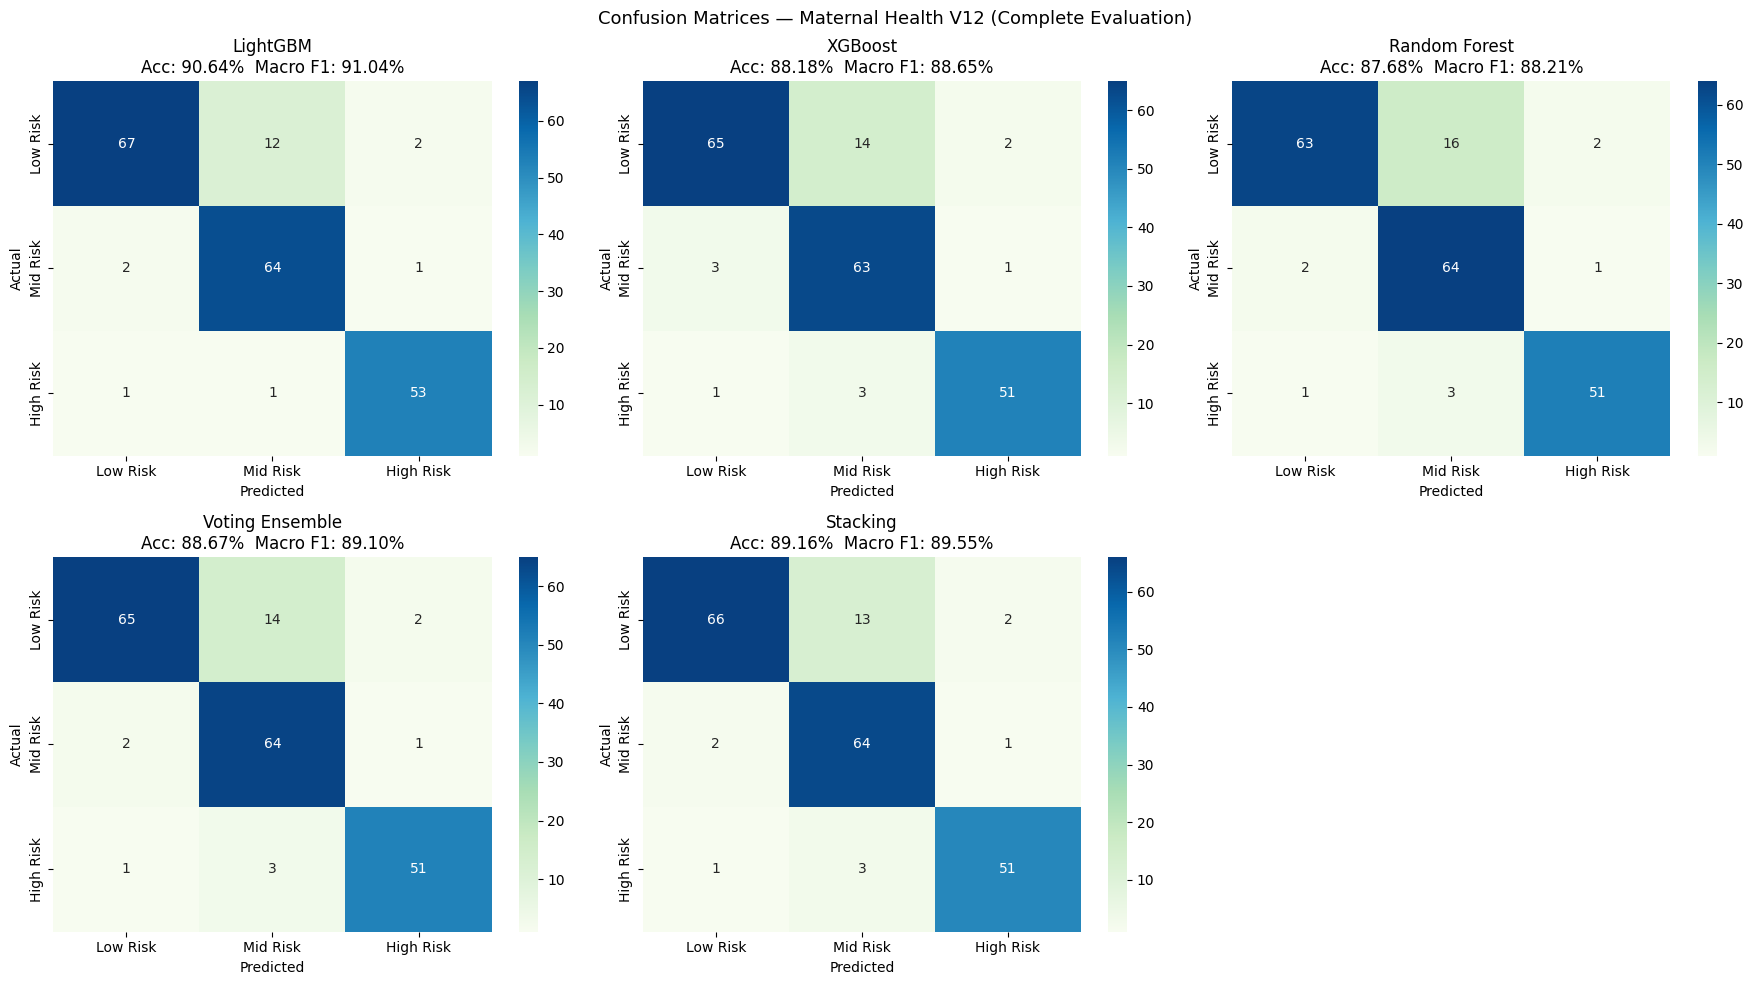

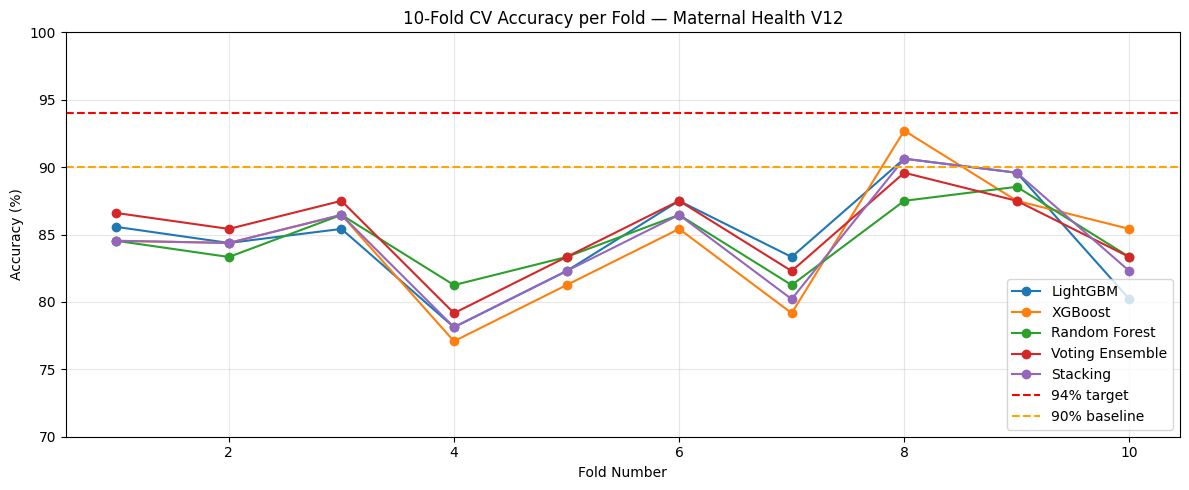

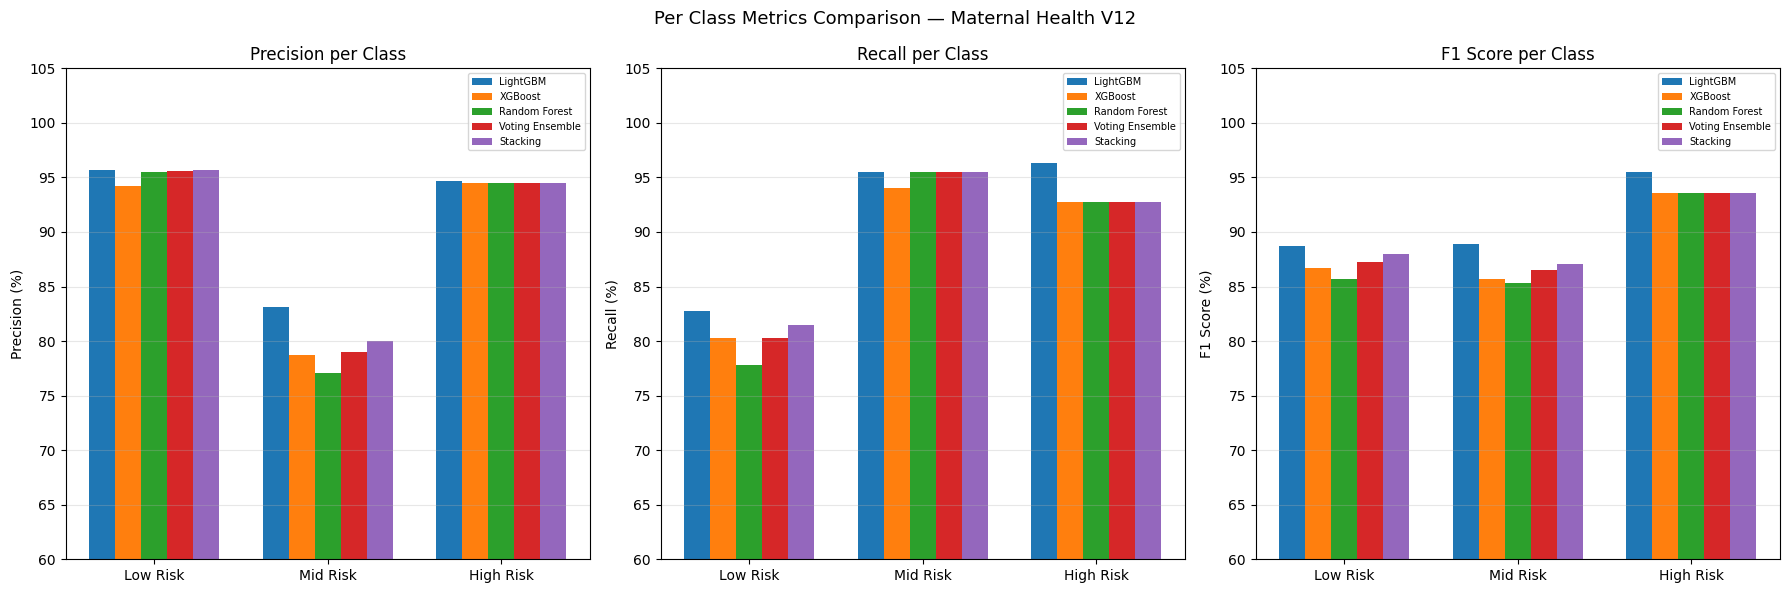


Complete medical ML evaluation done!

Key metrics for your report:
  Best Model:        LightGBM
  Test Accuracy:     90.64%
  Macro F1:          91.04%
  CV Mean ± Std:     84.70% ± 3.73%
  Weighted F1:       90.62%


In [17]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_score, recall_score)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("COMPLETE MEDICAL ML EVALUATION — Maternal Health V12")
print("="*70)

models_eval = {
    "LightGBM":        (lgb_best,     pred_lgb,     lgb_cv10),
    "XGBoost":         (xgb_best,     pred_xgb,     xgb_cv10),
    "Random Forest":   (rf_best,      pred_rf,      rf_cv10),
    "Voting Ensemble": (voting_clf,   pred_voting,  voting_cv10),
    "Stacking":        (stacking_clf, pred_stacking,stacking_cv10),
}

class_names = ["Low Risk", "Mid Risk", "High Risk"]

# ── 1. SUMMARY TABLE ──
print(f"\n{'Model':<20} {'Accuracy':>9} {'Macro F1':>9} {'Macro P':>9} "
      f"{'Macro R':>9} {'CV Mean':>9} {'CV Std':>9}")
print("-"*76)

for name, (model, pred, cv_scores) in models_eval.items():
    acc     = accuracy_score(y_test, pred)
    mac_f1  = f1_score(y_test, pred, average="macro")
    mac_p   = precision_score(y_test, pred, average="macro")
    mac_r   = recall_score(y_test, pred, average="macro")
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()

    print(f"{name:<20} {acc*100:>8.2f}% {mac_f1*100:>8.2f}% "
          f"{mac_p*100:>8.2f}% {mac_r*100:>8.2f}% "
          f"{cv_mean*100:>8.2f}% {cv_std*100:>8.2f}%")

# ── 2. PER CLASS BREAKDOWN — Best Model (LightGBM) ──
print("\n" + "="*70)
print("PER CLASS METRICS — LightGBM (Best Model)")
print("="*70)
print(f"\n{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1 Score':>10} {'Support':>10}")
print("-"*50)

p_scores = precision_score(y_test, pred_lgb, average=None)
r_scores = recall_score(y_test, pred_lgb, average=None)
f_scores = f1_score(y_test, pred_lgb, average=None)
supports = [sum(y_test == i) for i in range(3)]

for i, cls in enumerate(class_names):
    print(f"{cls:<15} {p_scores[i]*100:>9.2f}% {r_scores[i]*100:>9.2f}% "
          f"{f_scores[i]*100:>9.2f}% {supports[i]:>10}")

print(f"\n{'Macro Avg':<15} {p_scores.mean()*100:>9.2f}% "
      f"{r_scores.mean()*100:>9.2f}% {f_scores.mean()*100:>9.2f}%")
print(f"{'Weighted Avg':<15} "
      f"{precision_score(y_test, pred_lgb, average='weighted')*100:>9.2f}% "
      f"{recall_score(y_test, pred_lgb, average='weighted')*100:>9.2f}% "
      f"{f1_score(y_test, pred_lgb, average='weighted')*100:>9.2f}%")

# ── 3. OVERFITTING DIAGNOSTIC ──
print("\n" + "="*70)
print("OVERFITTING DIAGNOSTIC")
print("="*70)
print(f"\n{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'Verdict':>15}")
print("-"*65)

for name, (model, pred, cv_scores) in models_eval.items():
    train_pred = model.predict(X_train_scaled)
    tr_acc     = accuracy_score(y_train_raw, train_pred)
    te_acc     = accuracy_score(y_test, pred)
    gap        = tr_acc - te_acc

    if gap > 0.10:
        verdict = "OVERFITTING"
    elif gap > 0.05:
        verdict = "Mild overfit"
    elif gap < -0.02:
        verdict = "Test > Train"
    else:
        verdict = "Good fit"

    print(f"{name:<20} {tr_acc*100:>9.2f}% {te_acc*100:>9.2f}% "
          f"{gap*100:>7.2f}% {verdict:>15}")

# ── 4. CV MEAN ± STD TABLE ──
print("\n" + "="*70)
print("CROSS VALIDATION MEAN ± STD (10-Fold)")
print("="*70)
print(f"\n{'Model':<20} {'CV Mean':>10} {'CV Std':>10} {'Min Fold':>10} {'Max Fold':>10}")
print("-"*55)

for name, (model, pred, cv_scores) in models_eval.items():
    print(f"{name:<20} {cv_scores.mean()*100:>9.2f}% "
          f"{cv_scores.std()*100:>9.2f}%  "
          f"{cv_scores.min()*100:>9.2f}%  "
          f"{cv_scores.max()*100:>9.2f}%")

# ── 5. CONFUSION MATRICES ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (name, (model, pred, cv)) in zip(axes.flatten(), models_eval.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu", ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    acc    = accuracy_score(y_test, pred)
    mac_f1 = f1_score(y_test, pred, average="macro")
    ax.set_title(f"{name}\nAcc: {acc*100:.2f}%  Macro F1: {mac_f1*100:.2f}%")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[1][2].set_visible(False)
plt.suptitle("Confusion Matrices — Maternal Health V12 (Complete Evaluation)",
             fontsize=13)
plt.tight_layout()
plt.savefig("maternal_complete_evaluation.png")
plt.show()

# ── 6. CV DISTRIBUTION PLOT ──
fig, ax = plt.subplots(figsize=(12, 5))
for name, (model, pred, cv_scores) in models_eval.items():
    ax.plot(range(1, 11), cv_scores * 100, marker="o", label=name)

ax.axhline(y=94, color="red", linestyle="--", linewidth=1.5, label="94% target")
ax.axhline(y=90, color="orange", linestyle="--", linewidth=1.5, label="90% baseline")
ax.set_xlabel("Fold Number")
ax.set_ylabel("Accuracy (%)")
ax.set_title("10-Fold CV Accuracy per Fold — Maternal Health V12")
ax.legend(loc="lower right")
ax.set_ylim(70, 100)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("maternal_cv_distribution.png")
plt.show()

# ── 7. PER CLASS COMPARISON ACROSS ALL MODELS ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = {
    "Precision": precision_score,
    "Recall":    recall_score,
    "F1 Score":  f1_score
}

for ax, (metric_name, metric_fn) in zip(axes, metrics.items()):
    data = {}
    for name, (model, pred, cv) in models_eval.items():
        scores = metric_fn(y_test, pred, average=None)
        data[name] = scores

    x = np.arange(len(class_names))
    width = 0.15
    for i, (name, scores) in enumerate(data.items()):
        ax.bar(x + i * width, scores * 100, width, label=name)

    ax.set_title(f"{metric_name} per Class")
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(class_names)
    ax.set_ylabel(f"{metric_name} (%)")
    ax.set_ylim(60, 105)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Per Class Metrics Comparison — Maternal Health V12", fontsize=13)
plt.tight_layout()
plt.savefig("maternal_per_class_metrics.png")
plt.show()

print("\nComplete medical ML evaluation done!")
print("\nKey metrics for your report:")
print(f"  Best Model:        LightGBM")
print(f"  Test Accuracy:     {accuracy_score(y_test, pred_lgb)*100:.2f}%")
print(f"  Macro F1:          {f1_score(y_test, pred_lgb, average='macro')*100:.2f}%")
print(f"  CV Mean ± Std:     {lgb_cv10.mean()*100:.2f}% ± {lgb_cv10.std()*100:.2f}%")
print(f"  Weighted F1:       {f1_score(y_test, pred_lgb, average='weighted')*100:.2f}%")

Class order:  [0 1 2]


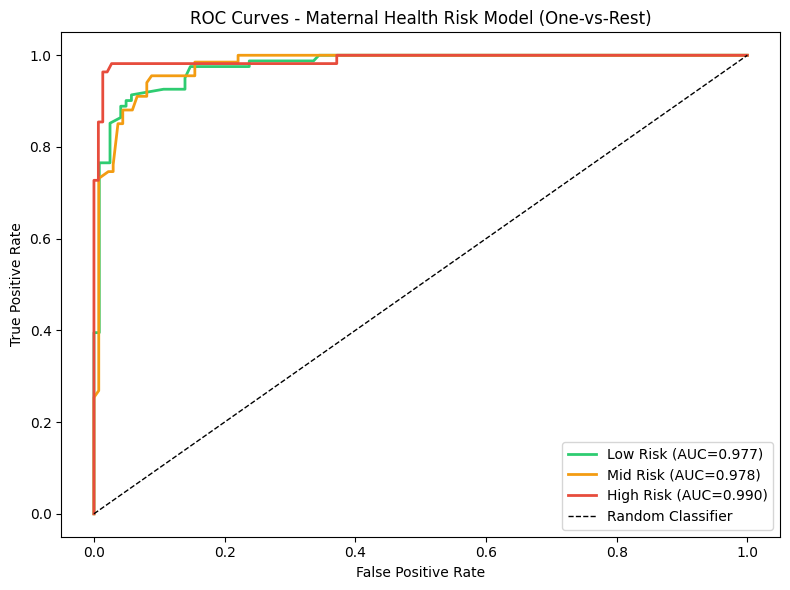

Low Risk AUC: 0.9770
Mid Risk AUC: 0.9782
High Risk AUC: 0.9905


In [20]:
from sklearn.metrics import roc_curve,auc
from sklearn.preprocessing import label_binarize

class_order=lgb_best.classes_
print("Class order: ",class_order)

y_test_bin=label_binarize(y_test,classes=class_order)
y_prob=lgb_best.predict_proba(X_test_scaled)

name_map={0:"Low Risk",1:"Mid Risk",2:"High Risk"}
colors=['#2ecc71','#f39c12','#e74c3c']

plt.figure(figsize=(8,6))

for i,cls in enumerate(class_order):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i],y_prob[:, i])
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,color=colors[i],lw=2,label=f'{name_map[cls]} (AUC={roc_auc:.3f})')

plt.plot([0,1],[0,1],"k--",lw=1,label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Maternal Health Risk Model (One-vs-Rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('maternal_roc_curves.png',dpi=300)
plt.show()

for i,cls in enumerate(class_order):
    fpr,tpr,_=roc_curve(y_test_bin[:,i],y_prob[:,i])
    print(f"{name_map[cls]} AUC: {auc(fpr,tpr):.4f}")